In [2]:
from scripts import plugin_loader  # noqa: F401
from scripts.abstract_pyprocessor import PyProcessor
import cv2
import matplotlib.pyplot as plt

Successfully loaded plugin: abstract_pyprocessor
Successfully loaded plugin: matched_filter_pyprocessor
Successfully loaded plugin: fmmorph_pyprocessor
Successfully loaded plugin: contour_pyprocessor


In [3]:
from pathlib import Path
from typing import Optional

images_directory = "../images/"
annotations_directory = "../images/annotated/"
processed_directory = "../processed/"


def get_file_name_from_stem(directory: str, target_stem: str) -> Optional[str]:
    search_directory = Path(directory)
    files = [f for f in search_directory.glob(f"{target_stem}.*") if f.is_file()]

    if files is None or len(files) < 1:
        print(f"No file with stem {target_stem} exists.")
        return None

    if len(files) > 1:
        print(
            f"Multiple files exist with stem {target_stem}. Please resolve these names."
        )
        return None

    return files[0].name

## Testing Environment
Defines environment variables required for testing.
- `images_directory`: directory to search for test images
- `annotations_directory`: directory to search for related annotation segmentation masks (denotes ground truth)
- `images`: dictionary holding test image to ground truth mappings
- `methods`: set of methods to test with the dispatcher in `PyProcessor`

In [4]:
images = {
    "0078.tif": "0078.png",
    "0079.tif": "0079.png",
    "0080.tif": "0080.png",
    "0081.tif": "0081.png",
    "0082.tif": "0082.png",
    "0083.tif": "0083.png",
    "0098.tif": "0098.png",
    "0099.tif": "0099.png",
    "0101.tif": "0101.png",
    "0102.tif": "0102.png",
    "0104.tif": "0104.png",
    "0105.tif": "0105.png",
    "0145.tif": "0145.png",
    "0146.tif": "0146.png",
    "0147.tif": "0147.png",
    "0148.tif": "0148.png",
    "0152.tif": "0152.png",
    "0154.tif": "0154.png",
    "0156.jpg": "0156.png",
    "0157.jpg": "0157.png",
    "0158.jpg": "0158.png",
    "0159.jpg": "0159.png",
    "0160.jpg": "0160.png",
    "0161.jpg": "0161.png",
    "0162.jpg": "0162.png",
    "0163.jpg": "0163.png",
    "0164.jpg": "0164.png",
    "0165.jpg": "0165.png",
    "0166.jpg": "0166.png",
    "0167.jpg": "0167.png",
    "0168.jpg": "0168.png",
    "0169.jpg": "0169.png",
}


def add_image_annotation_from_range(start: int, end: int) -> None:
    assert start >= 0 and end >= start and end < 9999
    for stem in range(start, end + 1):
        stem_str: str = f"{stem:04}"

        image_path = get_file_name_from_stem(images_directory, stem_str)
        annotation_path = get_file_name_from_stem(annotations_directory, stem_str)

        if image_path is None or annotation_path is None:
            continue

        images[image_path] = annotation_path


add_image_annotation_from_range(20, 38)
add_image_annotation_from_range(59, 67)
add_image_annotation_from_range(68, 73)
add_image_annotation_from_range(107, 110)

methods = {
    "mfccd",
    "mfgamma",
    "mfsigmoid",
    "mfhyst",
    "mfhgamma",
    "mfhsigmoid",
    "fmm",
    "smf",
    "pmf"
}

## Scoring Logic
Iterates over the image-annotation pairs within the `images` dictionary and processes each image according to each method denoted in the `methods` set. The results are scored based on the annotation (ground truth):
- Intersection over Union: approximation of worst-case performance
- Dice: approximation of average-case performance
- Percent error: total number of false positives and false negatives

In [5]:
from joblib import Memory
import pandas as pd
import seaborn as sns
from scripts import score
from utils import benchmark

cache_directory = "./__segcache__"
memory = Memory(cache_directory, verbose=0)


# @memory.cache
# def benchmark(image_path: str, annotation_path: str, method: str) -> dict:
#     image = cv2.imread(images_directory + image_path, cv2.IMREAD_GRAYSCALE)
#     assert image is not None

#     ground_truth = cv2.imread(
#         annotations_directory + annotation_path, cv2.IMREAD_GRAYSCALE
#     )
#     assert ground_truth is not None

#     PyProcessor.dispatch_execute(method, image)

#     cv2.imwrite(
#         f"{processed_directory}{method}_{image_path[: image_path.find('.')]}.png",
#         image,
#     )

#     return {
#         "image_path": image_path,
#         "method_name": method,
#         "iou": score.iou(image, ground_truth),
#         "dice": score.dice(image, ground_truth),
#         "percent_err": score.percent_err(image, ground_truth),
#     }

results = []

for image_path, annotation_path in images.items():
    for method in methods:
        # UNCOMMENT TO RERUN
        # benchmark.call(
        #     image_path=image_path, annotation_path=annotation_path, method=method
        # )

        results.append(benchmark(image_path, annotation_path, method))


In [6]:
df = pd.DataFrame(results)
df


,image_path,method_name,iou,dice,percent_err
0,0078.tif,fmm,0.539614,0.700973,0.032015
1,0078.tif,mfhyst,0.409208,0.580763,0.038985
2,0078.tif,smf,0.000000,0.000000,0.058105
3,0078.tif,pmf,0.412460,0.584031,0.037054
4,0078.tif,mfccd,0.420158,0.591706,0.036111
...,...,...,...,...,...
625,0110.tif,mfccd,0.038356,0.073878,0.064822
626,0110.tif,mfgamma,0.038356,0.073878,0.064822
627,0110.tif,mfhsigmoid,0.038356,0.073878,0.064822
628,0110.tif,mfsigmoid,0.038356,0.073878,0.064822


## Metric Distributions
With the number of images we've tested, results grouped by metric alone varied widely. IoU and Dice appear evenly distributed along the range [0.0, 0.9). Later on in this notebook, we threshold our results to see when methods start to increase in performance.

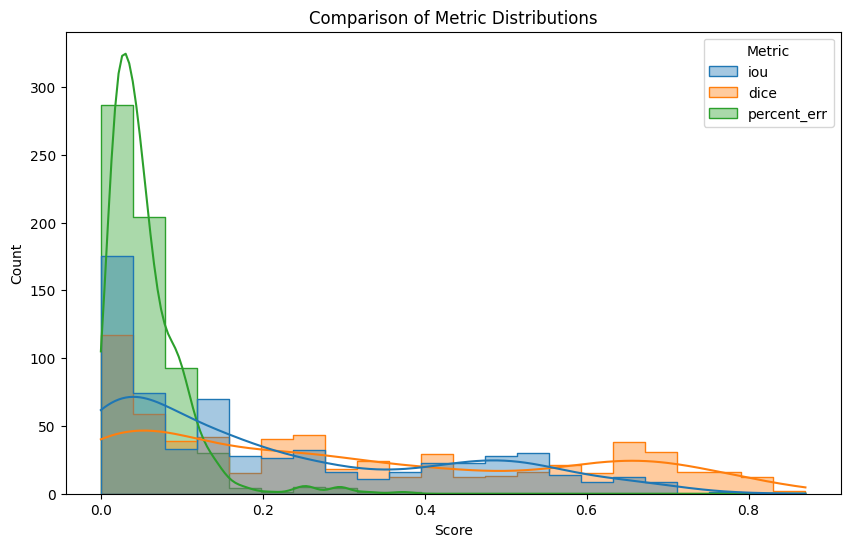

In [7]:
plt.figure(figsize=(10, 6))

# "melt" dataframe to make it compatible with Seaborn's multi-plot logic
df_melted = df.melt(
    value_vars=["iou", "dice", "percent_err"], var_name="Metric", value_name="Score"
)

# create the histogram with a KDE curve
sns.histplot(
    data=df_melted, x="Score", hue="Metric", kde=True, element="step", alpha=0.4
)

plt.title("Comparison of Metric Distributions")
plt.show()

## Method Distributions
Notice that the method type hardly played a factor in Dice score. Keep this in mind for later on.

Text(0.5, 0.98, 'Metric Performance by Method')

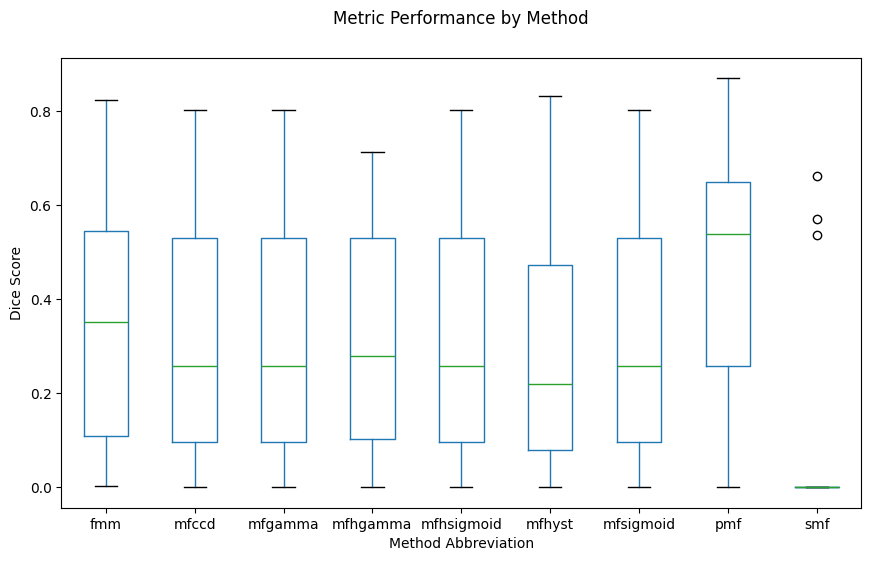

In [8]:
ax = df.boxplot(column='dice', by='method_name', figsize=(10, 6), grid=False)
ax.set(title=None)
ax.set_xlabel('Method Abbreviation')
ax.set_ylabel('Dice Score')
plt.suptitle('Metric Performance by Method')

In [9]:
method_performance = (
    df.groupby("method_name")[["iou", "dice", "percent_err"]]
    .mean()
    .sort_values(by="iou", ascending=False)
)
method_performance

,iou,dice,percent_err
method_name,,,
pmf,0.334117,0.464664,0.026048
fmm,0.245417,0.352521,0.041748
mfccd,0.216285,0.316078,0.068903
mfsigmoid,0.216285,0.316078,0.068903
mfgamma,0.216285,0.316078,0.068903
mfhsigmoid,0.216285,0.316078,0.068903
mfhgamma,0.206495,0.309301,0.031413
mfhyst,0.206053,0.299544,0.092496
smf,0.017983,0.025249,0.024970


## Pruning Results Based on IoU
Earlier in this notebook, we saw that IoU and Dice varied widely across all results. In order to get a better understanding why, it may be best to look at results with an IoU at or above a certain threshold.

> The plan is to find what kinds of images performed well, what kinds of images performed poorly, and what differentiates these two groups of images.

In [10]:
best_methods_per_image = (
    df.loc[df.groupby("image_path")["iou"].idxmax()][
        ["image_path", "method_name", "iou", "dice", "percent_err"]
    ]
    .set_index("image_path")
    .sort_values(by="iou", ascending=False)
)
best_methods_per_image

,method_name,iou,dice,percent_err
image_path,,,,
0070.bmp,pmf,0.770401,0.870312,0.009084
0098.tif,mfhyst,0.711939,0.831734,0.025036
0101.tif,mfhyst,0.708218,0.829190,0.024891
0165.jpg,pmf,0.686635,0.814207,0.008054
0104.tif,fmm,0.684899,0.812985,0.022236
...,...,...,...,...
0160.jpg,pmf,0.079318,0.146978,0.057118
0146.tif,mfhgamma,0.047556,0.090794,0.124001
0147.tif,mfhgamma,0.027278,0.053107,0.040628


In [11]:
best_methods_per_image[best_methods_per_image.index.str.match('016[0-9].jpg')]

,method_name,iou,dice,percent_err
image_path,,,,
0165.jpg,pmf,0.686635,0.814207,0.008054
0161.jpg,pmf,0.525436,0.688900,0.015345
0162.jpg,pmf,0.440271,0.611372,0.013905
0167.jpg,pmf,0.420067,0.591616,0.007093
0166.jpg,pmf,0.404476,0.575981,0.012329
0163.jpg,pmf,0.375065,0.545524,0.011678
0168.jpg,pmf,0.368081,0.538098,0.007742
0169.jpg,pmf,0.209791,0.346822,0.011595
0164.jpg,pmf,0.192750,0.323202,0.028729


In [12]:
df_failed = best_methods_per_image[best_methods_per_image["iou"] < 0.40]
df_failed[~df_failed.index.str.match('016[0-9].jpg')].sort_index()

,method_name,iou,dice,percent_err
image_path,,,,
0020.tif,fmm,0.240773,0.388102,0.039208
0021.tif,pmf,0.267976,0.422683,0.029462
0023.tif,pmf,0.127958,0.226884,0.017725
0024.tif,pmf,0.132893,0.234609,0.013041
0025.tif,pmf,0.178805,0.303366,0.017398
0026.tif,pmf,0.080047,0.148229,0.023560
0027.tif,pmf,0.118653,0.212135,0.033646
0030.tif,pmf,0.092488,0.169316,0.033506
0033.tif,pmf,0.110171,0.198476,0.030564


In [13]:
df_pruned = best_methods_per_image[best_methods_per_image["iou"] >= 0.40]
df_pruned

,method_name,iou,dice,percent_err
image_path,,,,
0070.bmp,pmf,0.770401,0.870312,0.009084
0098.tif,mfhyst,0.711939,0.831734,0.025036
0101.tif,mfhyst,0.708218,0.829190,0.024891
0165.jpg,pmf,0.686635,0.814207,0.008054
0104.tif,fmm,0.684899,0.812985,0.022236
0102.tif,fmm,0.674082,0.805316,0.023427
0099.tif,fmm,0.673501,0.804901,0.023781
0069.bmp,pmf,0.672805,0.804404,0.014233
0105.tif,fmm,0.649987,0.787869,0.025627


In [15]:
from utils import compare
from typing import cast

for row in df_pruned.itertuples():
    image_str : str = cast(str, row.Index)
    method_str : str = cast(str, row.method_name)
    compare(image_str, images[image_str], method_str)

Text(0.5, 0.98, 'Metric Performance by Method')

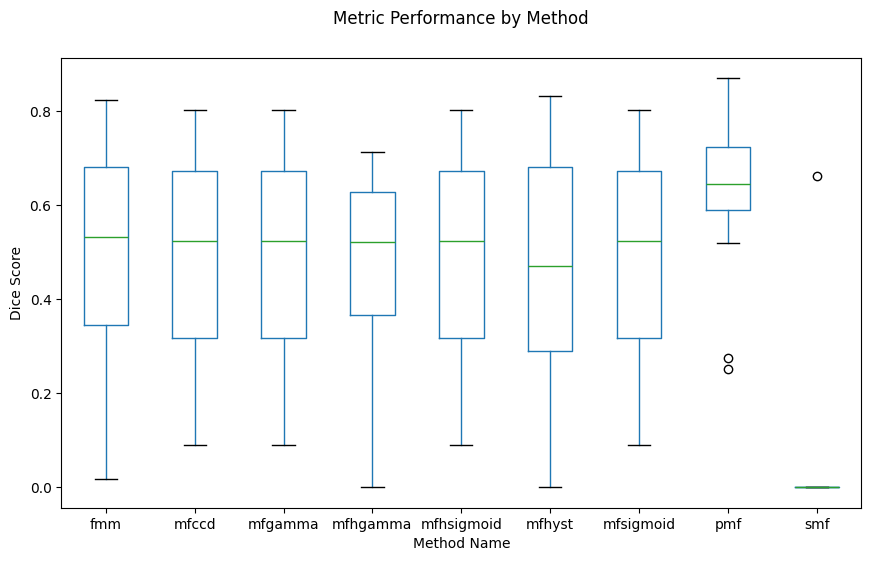

In [ ]:
df_filtered = df[df["image_path"].isin(df_pruned.index)]
ax = df_filtered.boxplot(
    column="dice", by="method_name", figsize=(10, 6), grid=False
)
ax.set(title=None)
ax.set_xlabel('Method Name')
ax.set_ylabel('Dice Score')
plt.suptitle('Metric Performance by Method')

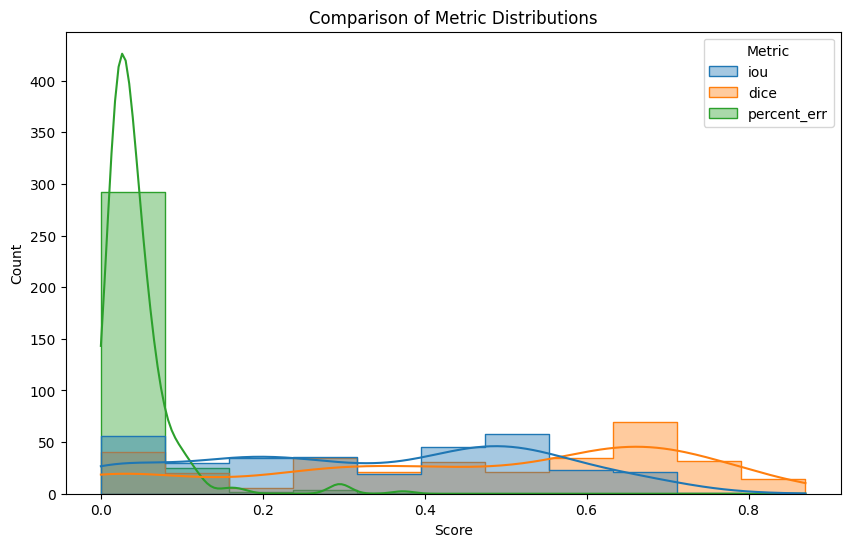

In [ ]:
plt.figure(figsize=(10, 6))

df_filtered_melted = df_filtered.melt(
    value_vars=["iou", "dice", "percent_err"], var_name="Metric", value_name="Score"
)

sns.histplot(
    data=df_filtered_melted,
    x="Score",
    hue="Metric",
    kde=True,
    element="step",
    alpha=0.4,
)

plt.title("Comparison of Metric Distributions")
plt.show()